## 17. Optimización de hiperparámetros con Manifold Mixup

In [1]:
import torch
import numpy as np

TARGET_SR = 16_000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5
TEST_SIZE = 0.20

%load_ext autoreload
%autoreload 2

print(f"Device: {DEVICE}")

Device: mps


In [2]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata
from sklearn.model_selection import train_test_split

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

labels_all = df_metadata["label"].to_numpy()

if TEST_SIZE > 0:
    train_idx, test_idx = train_test_split(
        np.arange(len(labels_all)),
        test_size=TEST_SIZE,
        stratify=labels_all,
        random_state=RANDOM_STATE,
    )
else:
    train_idx = np.arange(len(labels_all))
    test_idx = np.array([], dtype=int)

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")
print(f"Train PD={labels_all[train_idx].sum():.0f}, HC={len(train_idx) - labels_all[train_idx].sum():.0f}")

/Users/napster/Documents/upm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 80 | Test: 20
Train PD=40, HC=40


In [3]:
from src.embeddings import extract_multilayer_embeddings
from src.spectral import extract_spectral_features
from sklearn.preprocessing import StandardScaler

waveforms_all = [waveforms_processed[i] for i in train_idx] + [waveforms_processed[i] for i in test_idx]

w2v_layers = extract_multilayer_embeddings(waveforms_all, "facebook/wav2vec2-base", [0], DEVICE)
emb_w2v_L0 = w2v_layers[0]

MEL_CONFIG = {"sample_rate": TARGET_SR, "n_fft": 1024, "hop_length": 512, "n_mels": 128}
spectral_features = extract_spectral_features(waveforms_all, device=DEVICE, **MEL_CONFIG)

n_train = len(train_idx)

scaler_t = StandardScaler()
scaler_s = StandardScaler()

emb_t_train = scaler_t.fit_transform(emb_w2v_L0[:n_train])
emb_s_train = scaler_s.fit_transform(spectral_features[:n_train])

if TEST_SIZE > 0:
    emb_t_test = scaler_t.transform(emb_w2v_L0[n_train:])
    emb_s_test = scaler_s.transform(spectral_features[n_train:])
else:
    emb_t_test = np.array([])
    emb_s_test = np.array([])

labels_train = labels_all[train_idx]
labels_test = labels_all[test_idx] if TEST_SIZE > 0 else np.array([])

print(f"Embeddings: train={len(emb_t_train)}, test={len(emb_t_test)}")

2026-04-19 21:02:14,917 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-04-19 21:02:15,222 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-19 21:02:15,224 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-19 21:02:15,299 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-19 21:02:15,413 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-19 21:02:15,522 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-19 21:02:15,639 [INFO

  25/100
  50/100
  75/100


2026-04-19 21:02:21,755 [INFO] src.config: Generando mel-espectrogramas...
2026-04-19 21:02:21,816 [INFO] src.config:   100 espectrogramas generados
2026-04-19 21:02:21,817 [INFO] src.config:   Shape ejemplo: (128, 117)
2026-04-19 21:02:21,817 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...


  100/100


2026-04-19 21:02:22,115 [INFO] src.config:   25/100
2026-04-19 21:02:22,188 [INFO] src.config:   50/100
2026-04-19 21:02:22,262 [INFO] src.config:   75/100
2026-04-19 21:02:22,331 [INFO] src.config:   100/100
2026-04-19 21:02:22,332 [INFO] src.config:   Features espectrales: (100, 512)


Embeddings: train=80, test=20


In [4]:
def manifold_mixup_intraclass(emb_t, emb_s, labels, alpha, rng):
    aug_t, aug_s, aug_labels = [], [], []

    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2:
            continue
        for i in cls_idx:
            j = rng.choice(cls_idx[cls_idx != i])
            lam = rng.beta(alpha, alpha)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_labels.append(cls)

    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)

### Búsqueda de hiperparámetros con Optuna

Se optimizan los hiperparámetros del modelo **junto con** el α del Manifold Mixup.

In [5]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj = trial.suggest_categorical("dim_proj", [64, 128])
    dim_hidden = trial.suggest_categorical("dim_hidden", [64, 128])
    mixup_alpha = trial.suggest_float("mixup_alpha", 0.1, 1.0, step=0.1)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
        tr_emb_t, tr_emb_s = emb_t_train[tr_idx], emb_s_train[tr_idx]
        tr_labels = labels_train[tr_idx]

        rng = np.random.default_rng(RANDOM_STATE + fold_idx)
        aug_t, aug_s, aug_labels = manifold_mixup_intraclass(
            tr_emb_t, tr_emb_s, tr_labels, mixup_alpha, rng
        )

        tr_emb_t_aug = np.concatenate([tr_emb_t, aug_t])
        tr_emb_s_aug = np.concatenate([tr_emb_s, aug_s])
        tr_labels_aug = np.concatenate([tr_labels, aug_labels])

        train_ds = DualBranchDataset(tr_emb_t_aug, tr_emb_s_aug, tr_labels_aug, np.arange(len(tr_labels_aug)))
        val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, dropout=dropout,
            label_smoothing=label_smoothing, batch_size=batch_size,
            dim_proj=dim_proj, dim_hidden=dim_hidden,
            epochs=120, patience=20,
            scheduler_factor=0.5, scheduler_patience=7,
        )

        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return mean_auc - 0.5 * std_auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=120, show_progress_bar=True)

Best trial: 4. Best value: 0.896875: 100%|██████████| 120/120 [14:02<00:00,  7.02s/it]


In [6]:
best = study.best_trial
print(f"Mejor trial #{best.number}")
print(f"  Score (AUC - 0.5*std): {best.value:.4f}")
print(f"  AUC: {best.user_attrs['auc_mean']:.3f} ± {best.user_attrs['auc_std']:.3f}")
print(f"  Parámetros:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Mejor trial #4
  Score (AUC - 0.5*std): 0.8969
  AUC: 0.925 ± 0.056
  Parámetros:
    lr: 0.00022494641644194482
    weight_decay: 0.0021937596127713345
    dropout: 0.45000000000000007
    label_smoothing: 0.07500000000000001
    batch_size: 8
    dim_proj: 128
    dim_hidden: 128
    mixup_alpha: 0.6


### Búsqueda de hiperparámetros con Gaussian Noise

In [7]:
from src.embeddings import extract_multilayer_embeddings
from src.spectral import extract_spectral_features


def augment_waveform_noise(waveform, snr_db, rng):
    power_signal = np.mean(waveform ** 2)
    power_noise = power_signal / (10 ** (snr_db / 10))
    return waveform + rng.normal(0, np.sqrt(power_noise), size=waveform.shape)


def build_augmented_features(train_idx, snr_db, rng):
    waveforms_aug = []
    for idx in train_idx:
        waveforms_aug.append(augment_waveform_noise(waveforms_processed[idx], snr_db, rng))

    # Sin test cuando TEST_SIZE=0
    if TEST_SIZE > 0:
        waveforms_all = (
            [waveforms_processed[i] for i in train_idx]
            + waveforms_aug
            + [waveforms_processed[i] for i in test_idx]
        )
    else:
        waveforms_all = (
            [waveforms_processed[i] for i in train_idx]
            + waveforms_aug
        )

    w2v = extract_multilayer_embeddings(waveforms_all, "facebook/wav2vec2-base", [0], DEVICE)[0]
    spec = extract_spectral_features(waveforms_all, device=DEVICE, **MEL_CONFIG)

    n_tr = len(train_idx)
    n_aug = len(waveforms_aug)

    sc_t, sc_s = StandardScaler(), StandardScaler()
    emb_t_tr = sc_t.fit_transform(w2v[:n_tr + n_aug])
    emb_s_tr = sc_s.fit_transform(spec[:n_tr + n_aug])

    if TEST_SIZE > 0:
        emb_t_te = sc_t.transform(w2v[n_tr + n_aug:])
        emb_s_te = sc_s.transform(spec[n_tr + n_aug:])
    else:
        emb_t_te = np.array([])
        emb_s_te = np.array([])

    labels_tr = np.concatenate([labels_all[train_idx], labels_all[train_idx]])

    return emb_t_tr, emb_s_tr, labels_tr, emb_t_te, emb_s_te, n_tr

In [8]:
# Pre-computar embeddings para SNR candidatos
SNR_OPTIONS = [15, 20, 25, 30]
precomputed = {}

for snr in SNR_OPTIONS:
    print(f"Pre-computando embeddings para SNR={snr} dB...")
    rng = np.random.default_rng(RANDOM_STATE)
    precomputed[snr] = build_augmented_features(train_idx, snr, rng)

print("Listo.")

2026-04-12 23:47:25,603 [INFO] src.config:   Cargando facebook/wav2vec2-base...


Pre-computando embeddings para SNR=15 dB...


2026-04-12 23:47:26,078 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-12 23:47:26,184 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-12 23:47:26,367 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-12 23:47:26,556 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-12 23:47:26,818 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-12 23:47:27,011 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Fou

  25/180
  50/180
  75/180
  100/180
  125/180
  150/180


2026-04-12 23:47:31,687 [INFO] src.config: Generando mel-espectrogramas...


...

  25/180
  50/180
  75/180
  100/180
  125/180
  150/180


2026-04-12 23:47:50,189 [INFO] src.config: Generando mel-espectrogramas...


  175/180


2026-04-12 23:47:50,271 [INFO] src.config:   180 espectrogramas generados
2026-04-12 23:47:50,271 [INFO] src.config:   Shape ejemplo: (128, 117)
2026-04-12 23:47:50,272 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...
2026-04-12 23:47:50,470 [INFO] src.config:   25/180
2026-04-12 23:47:50,535 [INFO] src.config:   50/180
2026-04-12 23:47:50,597 [INFO] src.config:   75/180
2026-04-12 23:47:50,662 [INFO] src.config:   100/180
2026-04-12 23:47:50,726 [INFO] src.config:   125/180
2026-04-12 23:47:50,791 [INFO] src.config:   150/180
2026-04-12 23:47:50,853 [INFO] src.config:   175/180
2026-04-12 23:47:50,867 [INFO] src.config:   Features espectrales: (180, 512)


Listo.


### Busqueda con Optuna para Gaussian Noise

In [9]:
def objective_noise(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj = trial.suggest_categorical("dim_proj", [64, 128])
    dim_hidden = trial.suggest_categorical("dim_hidden", [64, 128])
    snr_db = trial.suggest_categorical("snr_db", SNR_OPTIONS)

    emb_t_tr, emb_s_tr, labels_tr, _, _, n_tr = precomputed[snr_db]

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    # Labels originales para split (solo primeros n_tr)
    labels_orig = labels_tr[:n_tr]

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_tr[:n_tr], labels_orig)):
        # Train: originales del fold + sus augmentadas (mismo índice + n_tr)
        tr_idx_aug = np.concatenate([tr_idx, tr_idx + n_tr])
        labels_fold = labels_tr[tr_idx_aug]

        train_ds = DualBranchDataset(emb_t_tr, emb_s_tr, labels_tr, tr_idx_aug)
        val_ds = DualBranchDataset(emb_t_tr, emb_s_tr, labels_tr, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, dropout=dropout,
            label_smoothing=label_smoothing, batch_size=batch_size,
            dim_proj=dim_proj, dim_hidden=dim_hidden,
            epochs=120, patience=20,
            scheduler_factor=0.5, scheduler_patience=7,
        )

        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return mean_auc - 0.5 * std_auc


study_noise = optuna.create_study(direction="maximize")
study_noise.optimize(objective_noise, n_trials=60, show_progress_bar=True)

Best trial: 32. Best value: 0.894112: 100%|██████████| 60/60 [06:14<00:00,  6.24s/it]


### Evaluación con mejores hiperparámetros

In [16]:
from sklearn.metrics import accuracy_score, recall_score, roc_curve

bp = study.best_params
mixup_alpha = bp["mixup_alpha"]
bp_model = {k: v for k, v in bp.items() if k != "mixup_alpha"}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []
fold_histories = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
    tr_emb_t, tr_emb_s = emb_t_train[tr_idx], emb_s_train[tr_idx]
    tr_labels = labels_train[tr_idx]

    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_labels = manifold_mixup_intraclass(
        tr_emb_t, tr_emb_s, tr_labels, mixup_alpha, rng
    )

    tr_emb_t_aug = np.concatenate([tr_emb_t, aug_t])
    tr_emb_s_aug = np.concatenate([tr_emb_s, aug_s])
    tr_labels_aug = np.concatenate([tr_labels, aug_labels])

    train_ds = DualBranchDataset(tr_emb_t_aug, tr_emb_s_aug, tr_labels_aug, np.arange(len(tr_labels_aug)))
    val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

    y_true, y_prob, _, history = train_fold_regularized(
        train_ds, val_ds, DEVICE, **bp_model
    )

    auc = roc_auc_score(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_sens.append(sens)
    fold_spec.append(spec)
    fold_histories.append(history)

    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nCV Mixup Optimizado: AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f} | "
      f"Acc={np.mean(fold_accs):.3f}±{np.std(fold_accs):.3f} | "
      f"Sens={np.mean(fold_sens):.3f}±{np.std(fold_sens):.3f} | "
      f"Spec={np.mean(fold_spec):.3f}±{np.std(fold_spec):.3f}")

Fold 1: AUC=0.922 | Acc=0.875 | Sens=0.875 | Spec=1.000
Fold 2: AUC=0.891 | Acc=0.688 | Sens=0.750 | Spec=1.000
Fold 3: AUC=0.922 | Acc=0.875 | Sens=0.750 | Spec=1.000
Fold 4: AUC=0.906 | Acc=0.875 | Sens=0.750 | Spec=1.000
Fold 5: AUC=0.766 | Acc=0.562 | Sens=0.625 | Spec=0.500

CV Mixup Optimizado: AUC=0.881±0.059 | Acc=0.775±0.129 | Sens=0.750±0.079 | Spec=0.900±0.200


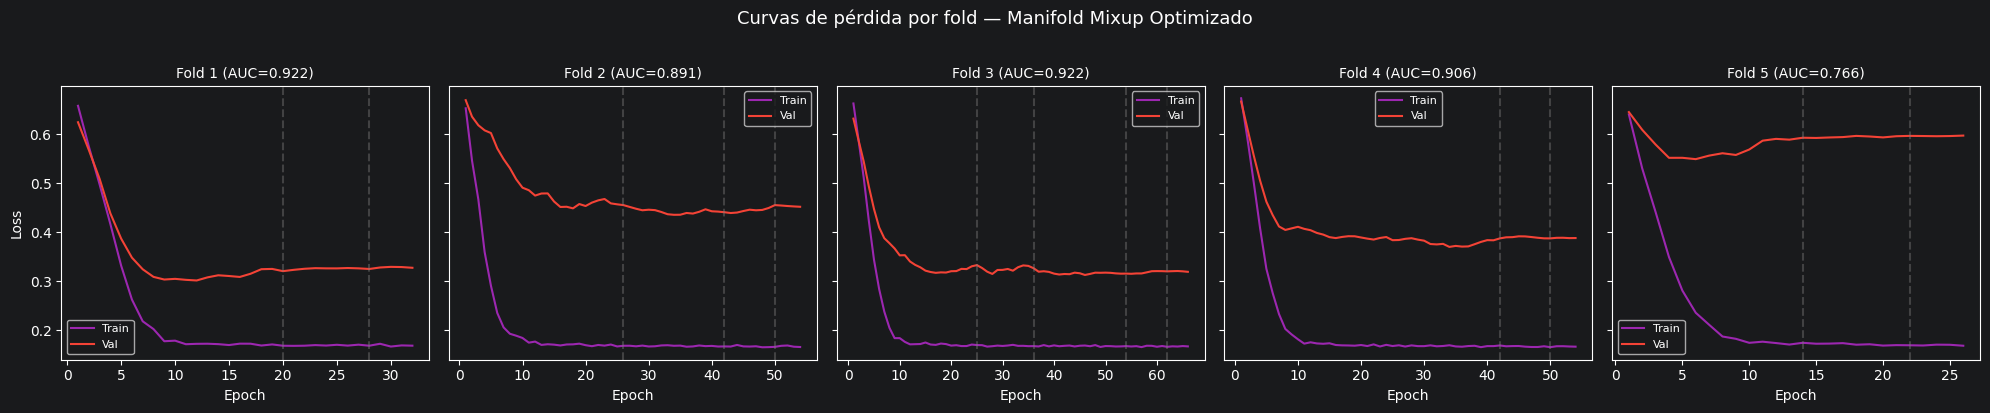

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4), sharey=True)

for i, (ax, hist) in enumerate(zip(axes, fold_histories)):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label="Train", linewidth=1.5, color="#9C27B0")
    ax.plot(epochs, hist["val_loss"],   label="Val",   linewidth=1.5, color="#F44336")

    for j, lr_val in enumerate(hist["lr"]):
        if j > 0 and lr_val < hist["lr"][j-1]:
            ax.axvline(j+1, color="gray", linestyle="--", alpha=0.4)

    ax.set_title(f"Fold {i+1} (AUC={fold_aucs[i]:.3f})", fontsize=10)
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

plt.suptitle("Curvas de pérdida por fold — Manifold Mixup Optimizado", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Test holdout: Baseline vs. Mixup optimizado

In [11]:
import matplotlib.pyplot as plt

N_SEEDS = 5

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === BASELINE ===
bl_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    bl_probs.append(y_prob)

bl_prob = np.mean(bl_probs, axis=0)
bl_pred = (bl_prob >= 0.5).astype(int)
bl_m = compute_metrics(y_true, bl_prob, bl_pred)

# === MANIFOLD MIXUP OPTIMIZADO ===
rng_mm = np.random.default_rng(RANDOM_STATE)
aug_t, aug_s, aug_lab = manifold_mixup_intraclass(emb_t_train, emb_s_train, labels_train, bp["mixup_alpha"], rng_mm)

emb_t_mm = np.concatenate([emb_t_train, aug_t])
emb_s_mm = np.concatenate([emb_s_train, aug_s])
labels_mm = np.concatenate([labels_train, aug_lab])

mm_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_mm, emb_s_mm, labels_mm, np.arange(len(labels_mm)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    mm_probs.append(y_prob)

mm_prob = np.mean(mm_probs, axis=0)
mm_pred = (mm_prob >= 0.5).astype(int)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA ===
print("=" * 60)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Δ':>10}")
print(f"  {'─' * 45}")
for name, bl, mm in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {mm - bl:>+10.3f}")

Test Holdout (ensemble 5 seeds)
  Métrica           Baseline  Mixup Opt          Δ
  ─────────────────────────────────────────────
  AUC                  0.850      0.840     -0.010
  Accuracy             0.700      0.750     +0.050
  Sensibilidad         0.800      0.800     +0.000
  Especificidad        0.800      0.800     +0.000


Test Holdout (ensemble 5 seeds)
  Métrica           Baseline  Mixup Opt  Noise Opt
  ───────────────────────────────────────────────────────
  AUC                  0.850      0.840      0.790
  Accuracy             0.700      0.750      0.700
  Sensibilidad         0.800      0.800      0.800
  Especificidad        0.800      0.800      1.000


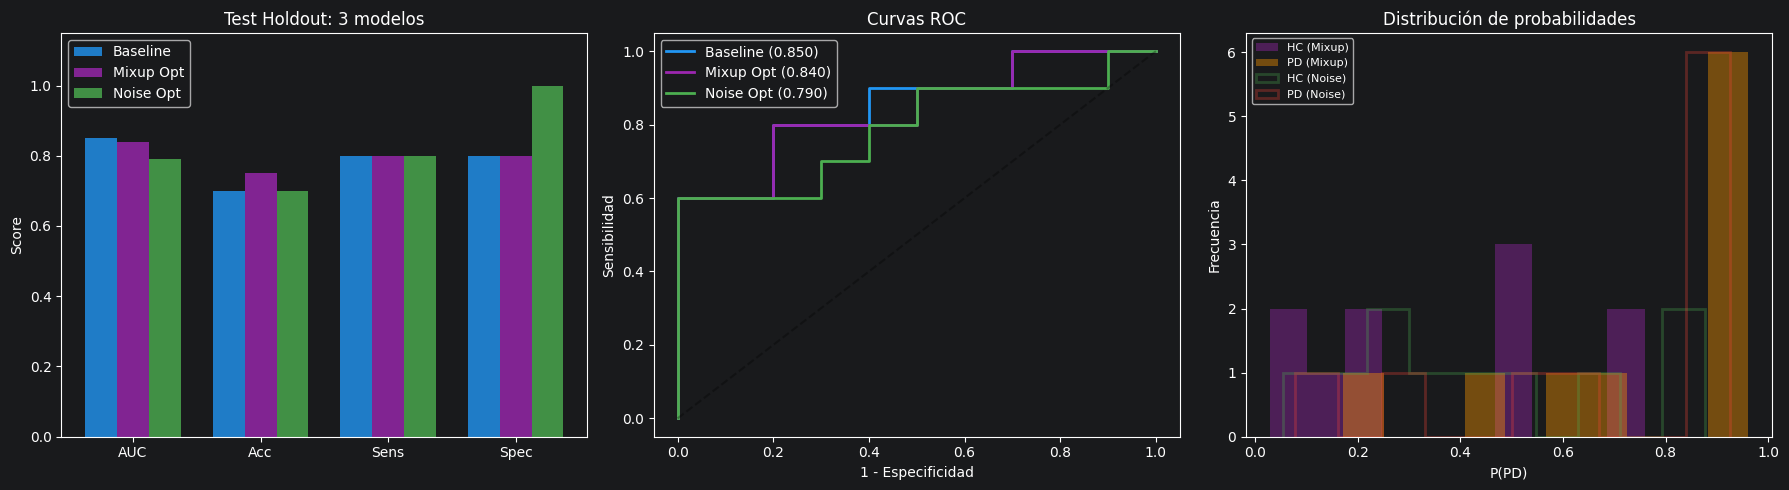

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score
import matplotlib.pyplot as plt

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === GAUSSIAN NOISE OPTIMIZADO ===
bp_n = study_noise.best_params
snr_opt = bp_n["snr_db"]
emb_t_tr_n, emb_s_tr_n, labels_tr_n, emb_t_te_n, emb_s_te_n, n_tr_n = precomputed[snr_opt]

gn_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_tr_n, emb_s_tr_n, labels_tr_n, np.arange(len(labels_tr_n)))
    test_ds = DualBranchDataset(emb_t_te_n, emb_s_te_n, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp_n["lr"], weight_decay=bp_n["weight_decay"],
        dropout=bp_n["dropout"], label_smoothing=bp_n["label_smoothing"],
        batch_size=bp_n["batch_size"], dim_proj=bp_n["dim_proj"],
        dim_hidden=bp_n["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    gn_probs.append(y_prob)

gn_prob = np.mean(gn_probs, axis=0)
gn_pred = (gn_prob >= 0.5).astype(int)
gn_m = compute_metrics(y_true, gn_prob, gn_pred)

# Recalcular bl_m y mm_m con la misma función local
bl_m = compute_metrics(y_true, bl_prob, bl_pred)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA 3 MODELOS ===
print("=" * 70)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 70)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Noise Opt':>10}")
print(f"  {'─' * 55}")
for name, bl, mm, gn in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m, gn_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {gn:>10.3f}")

# === GRÁFICOS 3 MODELOS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(4); width = 0.25
ax.bar(x - width, bl_m, width, label="Baseline", color="#2196F3", alpha=0.8)
ax.bar(x, mm_m, width, label="Mixup Opt", color="#9C27B0", alpha=0.8)
ax.bar(x + width, gn_m, width, label="Noise Opt", color="#4CAF50", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(["AUC", "Acc", "Sens", "Spec"])
ax.set_ylim(0, 1.15); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Test Holdout: 3 modelos")

ax = axes[1]
fpr_bl, tpr_bl, _ = roc_curve(y_true, bl_prob)
fpr_mm, tpr_mm, _ = roc_curve(y_true, mm_prob)
fpr_gn, tpr_gn, _ = roc_curve(y_true, gn_prob)
ax.plot(fpr_bl, tpr_bl, color="#2196F3", linewidth=2, label=f"Baseline ({bl_m[0]:.3f})")
ax.plot(fpr_mm, tpr_mm, color="#9C27B0", linewidth=2, label=f"Mixup Opt ({mm_m[0]:.3f})")
ax.plot(fpr_gn, tpr_gn, color="#4CAF50", linewidth=2, label=f"Noise Opt ({gn_m[0]:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("1 - Especificidad"); ax.set_ylabel("Sensibilidad")
ax.set_title("Curvas ROC"); ax.legend()

ax = axes[2]
ax.hist(mm_prob[y_true == 0], bins=10, alpha=0.4, color="#9C27B0", label="HC (Mixup)")
ax.hist(mm_prob[y_true == 1], bins=10, alpha=0.4, color="#FF9800", label="PD (Mixup)")
ax.hist(gn_prob[y_true == 0], bins=10, alpha=0.3, edgecolor="#4CAF50", linewidth=2, histtype="step", label="HC (Noise)")
ax.hist(gn_prob[y_true == 1], bins=10, alpha=0.3, edgecolor="#F44336", linewidth=2, histtype="step", label="PD (Noise)")
ax.set_xlabel("P(PD)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score

N_SEEDS = 5
mixup_alpha = bp["mixup_alpha"]
bp_model = {k: v for k, v in bp.items() if k != "mixup_alpha"}

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === BASELINE ===
bl_probs, bl_histories = [], []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, hist = train_fold_regularized(train_ds, test_ds, DEVICE, **bp_model)
    bl_probs.append(y_prob)
    bl_histories.append(hist)

bl_prob = np.mean(bl_probs, axis=0)
bl_pred = (bl_prob >= 0.5).astype(int)
bl_m = compute_metrics(y_true, bl_prob, bl_pred)

# === MIXUP OPTIMIZADO ===
rng_mm = np.random.default_rng(RANDOM_STATE)
aug_t, aug_s, aug_l = manifold_mixup_intraclass(emb_t_train, emb_s_train, labels_train, mixup_alpha, rng_mm)
emb_t_mm = np.concatenate([emb_t_train, aug_t])
emb_s_mm = np.concatenate([emb_s_train, aug_s])
labels_mm = np.concatenate([labels_train, aug_l])

mm_probs, mm_histories = [], []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_mm, emb_s_mm, labels_mm, np.arange(len(labels_mm)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, hist = train_fold_regularized(train_ds, test_ds, DEVICE, **bp_model)
    mm_probs.append(y_prob)
    mm_histories.append(hist)

mm_prob = np.mean(mm_probs, axis=0)
mm_pred = (mm_prob >= 0.5).astype(int)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA ===
print("=" * 60)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Δ':>10}")
print(f"  {'─' * 45}")
for name, bl, mm in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {mm - bl:>+10.3f}")

Test Holdout (ensemble 5 seeds)
  Métrica           Baseline  Mixup Opt          Δ
  ─────────────────────────────────────────────
  AUC                  0.850      0.840     -0.010
  Accuracy             0.700      0.750     +0.050
  Sensibilidad         0.800      0.800     +0.000
  Especificidad        0.800      0.800     +0.000


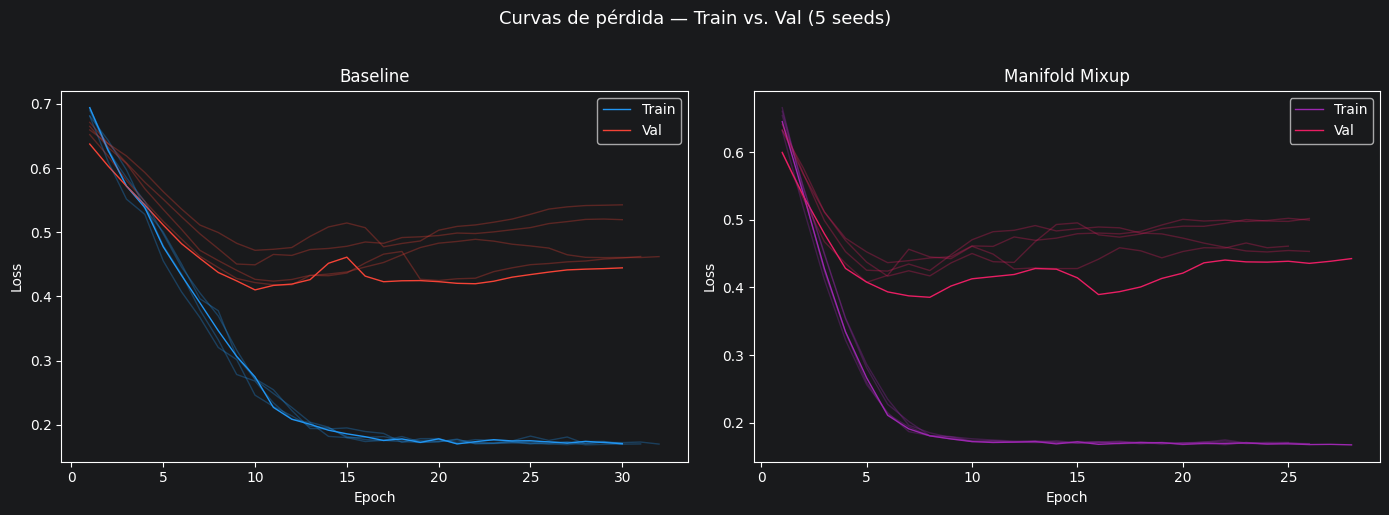

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Baseline", "Manifold Mixup"]
all_hist = [bl_histories, mm_histories]
colors_train = ["#2196F3", "#9C27B0"]
colors_val = ["#F44336", "#E91E63"]

for ax, title, histories, ct, cv in zip(axes, titles, all_hist, colors_train, colors_val):
    for seed, hist in enumerate(histories):
        epochs = range(1, len(hist["train_loss"]) + 1)
        alpha = 0.3 if seed > 0 else 1.0
        label_tr = "Train" if seed == 0 else None
        label_val = "Val" if seed == 0 else None
        ax.plot(epochs, hist["train_loss"], color=ct, alpha=alpha, linewidth=1, label=label_tr)
        ax.plot(epochs, hist["val_loss"], color=cv, alpha=alpha, linewidth=1, label=label_val)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.suptitle("Curvas de pérdida — Train vs. Val (5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
def cv_pearson(values):
    return (np.std(values) / np.mean(values)) * 100 if np.mean(values) != 0 else 0

def metrics_per_seed(probs_list, y_true):
    aucs, accs, senss, specs = [], [], [], []
    for y_prob in probs_list:
        y_pred = (y_prob >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_true, y_prob))
        accs.append(accuracy_score(y_true, y_pred))
        senss.append(recall_score(y_true, y_pred, pos_label=1))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        specs.append(1 - fpr[np.argmax(tpr - fpr)])
    return aucs, accs, senss, specs

bl_seeds = metrics_per_seed(bl_probs, y_true)
mm_seeds = metrics_per_seed(mm_probs, y_true)

print("=" * 60)
print("Coeficiente de Variación de Pearson (CV%) — 5 seeds")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>12} {'Mixup Opt':>12}")
print(f"  {'─' * 39}")
for name, bl_s, mm_s in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    bl_seeds, mm_seeds
):
    print(f"  {name:<15} {cv_pearson(bl_s):>11.2f}% {cv_pearson(mm_s):>11.2f}%")

print(f"\n{'=' * 60}")
print("Media ± Std por seed")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>16} {'Mixup Opt':>16}")
print(f"  {'─' * 47}")
for name, bl_s, mm_s in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    bl_seeds, mm_seeds
):
    print(f"  {name:<15} {np.mean(bl_s):.3f}±{np.std(bl_s):.3f}  "
          f"{np.mean(mm_s):.3f}±{np.std(mm_s):.3f}")

Coeficiente de Variación de Pearson (CV%) — 5 seeds
  Métrica             Baseline    Mixup Opt
  ───────────────────────────────────────
  AUC                    3.44%        2.07%
  Accuracy               9.04%        5.48%
  Sensibilidad          10.81%        9.13%
  Especificidad          9.30%       13.95%

Media ± Std por seed
  Métrica                 Baseline        Mixup Opt
  ───────────────────────────────────────────────
  AUC             0.854±0.029  0.844±0.017
  Accuracy        0.700±0.063  0.730±0.040
  Sensibilidad    0.740±0.080  0.820±0.075
  Especificidad   0.860±0.080  0.860±0.120


### Repeated Stratified K-Fold + Bootstrap (Intervalos de Confianza al 95%)

Se repite el 5-fold CV 10 veces con diferentes seeds (50 evaluaciones totales) para obtener una distribución robusta de métricas. Luego se aplica bootstrap (1000 remuestreos) para construir intervalos de confianza al 95%.

In [6]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

N_REPEATS = 10
N_FOLDS = 5

# Hiperparámetros óptimos del Mixup (copiados de Optuna trial #72)
mixup_alpha = 0.8
bp_model = {
    "lr": 0.0007839314160797212,
    "weight_decay": 0.0002939827898456091,
    "dropout": 0.30,
    "label_smoothing": 0.0,
    "batch_size": 8,
    "dim_proj": 128,
    "dim_hidden": 64,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}

rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)

bl_results = {"auc": [], "acc": [], "sens": [], "spec": []}
mm_results = {"auc": [], "acc": [], "sens": [], "spec": []}

for fold_idx, (tr_idx, val_idx) in enumerate(rskf.split(emb_t_train, labels_train)):
    tr_t, tr_s, tr_l = emb_t_train[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]

    # === BASELINE ===
    train_ds = DualBranchDataset(tr_t, tr_s, tr_l, np.arange(len(tr_l)))
    val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

    y_true, y_prob, _, _ = train_fold_regularized(train_ds, val_ds, DEVICE, **bp_model)

    y_pred = (y_prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    bl_results["auc"].append(roc_auc_score(y_true, y_prob))
    bl_results["acc"].append(accuracy_score(y_true, y_pred))
    bl_results["sens"].append(recall_score(y_true, y_pred, pos_label=1))
    bl_results["spec"].append(1 - fpr[np.argmax(tpr - fpr)])

    # === MANIFOLD MIXUP ===
    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_l = manifold_mixup_intraclass(tr_t, tr_s, tr_l, mixup_alpha, rng)

    train_ds_mm = DualBranchDataset(
        np.concatenate([tr_t, aug_t]),
        np.concatenate([tr_s, aug_s]),
        np.concatenate([tr_l, aug_l]),
        np.arange(len(tr_l) + len(aug_l))
    )

    y_true, y_prob, _, _ = train_fold_regularized(train_ds_mm, val_ds, DEVICE, **bp_model)

    y_pred = (y_prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    mm_results["auc"].append(roc_auc_score(y_true, y_prob))
    mm_results["acc"].append(accuracy_score(y_true, y_pred))
    mm_results["sens"].append(recall_score(y_true, y_pred, pos_label=1))
    mm_results["spec"].append(1 - fpr[np.argmax(tpr - fpr)])

    if (fold_idx + 1) % N_FOLDS == 0:
        rep = (fold_idx + 1) // N_FOLDS
        print(f"Repetición {rep}/{N_REPEATS} completada")

print(f"\nTotal evaluaciones: {len(bl_results['auc'])}")

Repetición 1/10 completada
Repetición 2/10 completada
Repetición 3/10 completada
Repetición 4/10 completada
Repetición 5/10 completada
Repetición 6/10 completada
Repetición 7/10 completada
Repetición 8/10 completada
Repetición 9/10 completada
Repetición 10/10 completada

Total evaluaciones: 50


In [7]:
def bootstrap_ci(values, n_bootstrap=1000, ci=95, seed=42):
    """Bootstrap interval de confianza."""
    rng = np.random.default_rng(seed)
    values = np.array(values)
    boot_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(values), lower, upper

# === TABLA CON INTERVALOS DE CONFIANZA ===
print("=" * 85)
print(f"Repeated {N_FOLDS}-Fold CV ({N_REPEATS} repeticiones = {N_REPEATS * N_FOLDS} evaluaciones)")
print("Bootstrap IC 95% (1000 remuestreos)")
print("=" * 85)
print(f"  {'Métrica':<15} {'Baseline':>25} {'Manifold Mixup':>25}")
print(f"  {'─' * 65}")

for metric in ["auc", "acc", "sens", "spec"]:
    name = {"auc": "AUC", "acc": "Accuracy", "sens": "Sensibilidad", "spec": "Especificidad"}[metric]

    bl_mean, bl_lo, bl_hi = bootstrap_ci(bl_results[metric])
    mm_mean, mm_lo, mm_hi = bootstrap_ci(mm_results[metric])

    print(f"  {name:<15} {bl_mean:.3f} [{bl_lo:.3f}, {bl_hi:.3f}]  {mm_mean:.3f} [{mm_lo:.3f}, {mm_hi:.3f}]")

# CV de Pearson
print(f"\n{'=' * 85}")
print("CV de Pearson (%)")
print("=" * 85)
print(f"  {'Métrica':<15} {'Baseline':>12} {'Mixup':>12}")
print(f"  {'─' * 39}")
for metric in ["auc", "acc", "sens", "spec"]:
    name = {"auc": "AUC", "acc": "Accuracy", "sens": "Sensibilidad", "spec": "Especificidad"}[metric]
    bl_cv = (np.std(bl_results[metric]) / np.mean(bl_results[metric])) * 100
    mm_cv = (np.std(mm_results[metric]) / np.mean(mm_results[metric])) * 100
    print(f"  {name:<15} {bl_cv:>11.2f}% {mm_cv:>11.2f}%")

Repeated 5-Fold CV (10 repeticiones = 50 evaluaciones)
Bootstrap IC 95% (1000 remuestreos)
  Métrica                          Baseline            Manifold Mixup
  ─────────────────────────────────────────────────────────────────
  AUC             0.893 [0.873, 0.914]  0.892 [0.871, 0.913]
  Accuracy        0.823 [0.797, 0.849]  0.812 [0.787, 0.838]
  Sensibilidad    0.810 [0.770, 0.848]  0.810 [0.770, 0.853]
  Especificidad   0.932 [0.905, 0.958]  0.927 [0.895, 0.955]

CV de Pearson (%)
  Métrica             Baseline        Mixup
  ───────────────────────────────────────
  AUC                    7.92%        8.28%
  Accuracy              10.46%       10.77%
  Sensibilidad          15.51%       16.97%
  Especificidad         10.46%       11.78%


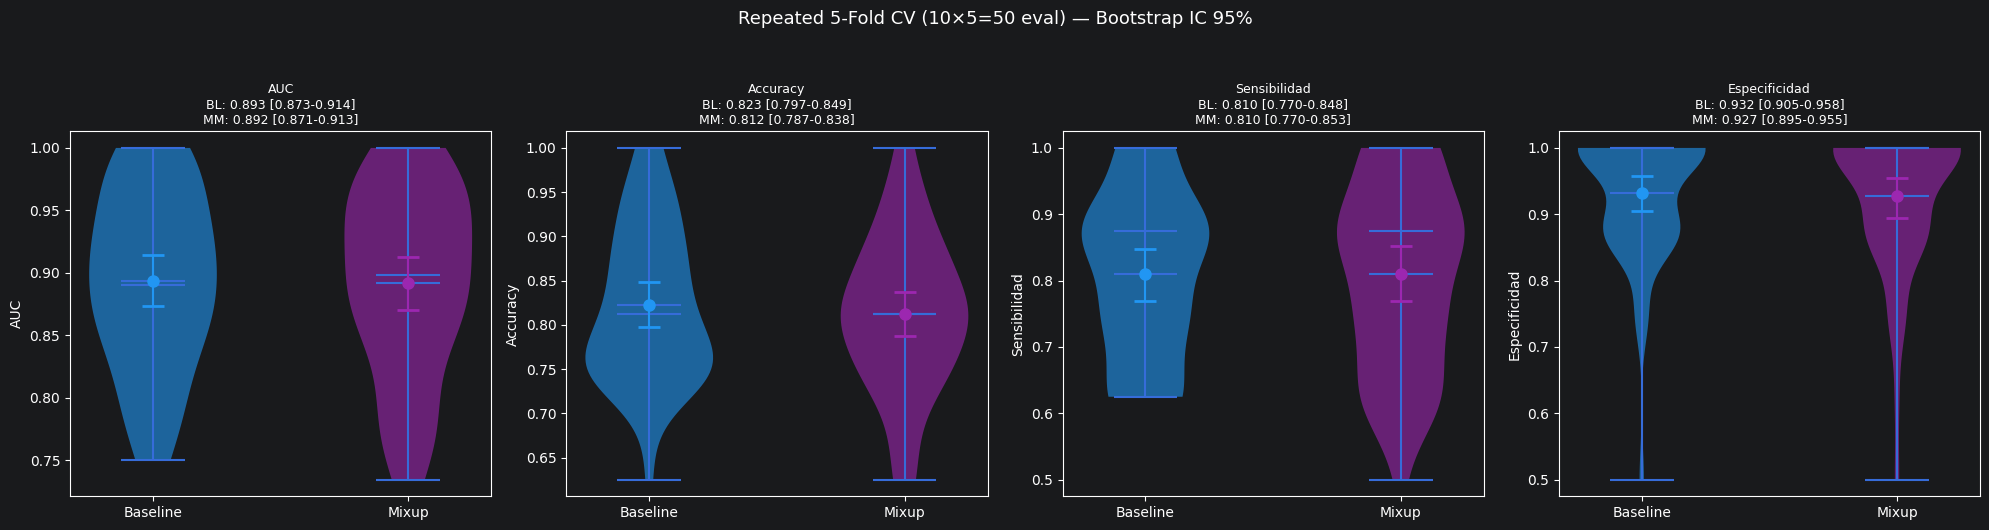

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ["auc", "acc", "sens", "spec"]
names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]

for ax, metric, name in zip(axes, metrics, names):
    bl_vals = bl_results[metric]
    mm_vals = mm_results[metric]

    parts = ax.violinplot([bl_vals, mm_vals], positions=[0, 1], showmeans=True, showmedians=True)

    for i, color in enumerate(["#2196F3", "#9C27B0"]):
        parts["bodies"][i].set_facecolor(color)
        parts["bodies"][i].set_alpha(0.6)

    # IC 95%
    bl_mean, bl_lo, bl_hi = bootstrap_ci(bl_vals)
    mm_mean, mm_lo, mm_hi = bootstrap_ci(mm_vals)

    ax.errorbar(0, bl_mean, yerr=[[bl_mean - bl_lo], [bl_hi - bl_mean]],
                fmt='o', color="#2196F3", capsize=8, capthick=2, markersize=8)
    ax.errorbar(1, mm_mean, yerr=[[mm_mean - mm_lo], [mm_hi - mm_mean]],
                fmt='o', color="#9C27B0", capsize=8, capthick=2, markersize=8)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Baseline", "Mixup"])
    ax.set_title(f"{name}\nBL: {bl_mean:.3f} [{bl_lo:.3f}-{bl_hi:.3f}]\nMM: {mm_mean:.3f} [{mm_lo:.3f}-{mm_hi:.3f}]",
                 fontsize=9)
    ax.set_ylabel(name)

plt.suptitle(f"Repeated {N_FOLDS}-Fold CV ({N_REPEATS}×{N_FOLDS}={N_REPEATS*N_FOLDS} eval) — Bootstrap IC 95%",
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### ¿Aumentar más datos mejora, empeora o queda igual?

Se evalúa el efecto de generar 1, 2, 3 y 4 muestras Mixup por sujeto usando Repeated 5-Fold CV (10 repeticiones = 50 evaluaciones) con bootstrap IC 95%.

In [9]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

N_REPEATS = 10
N_FOLDS = 5
N_AUG_OPTIONS = [0, 1, 2, 3, 4]  # 0 = baseline

mixup_alpha = 0.8
bp_model = {
    "lr": 0.0007839314160797212,
    "weight_decay": 0.0002939827898456091,
    "dropout": 0.30,
    "label_smoothing": 0.0,
    "batch_size": 8,
    "dim_proj": 128,
    "dim_hidden": 64,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}


def manifold_mixup_n(emb_t, emb_s, labels, alpha, n_aug, rng):
    """Genera n_aug muestras mixup por sujeto."""
    aug_t, aug_s, aug_labels = [], [], []
    for _ in range(n_aug):
        for cls in [0, 1]:
            cls_idx = np.where(labels == cls)[0]
            if len(cls_idx) < 2:
                continue
            for i in cls_idx:
                j = rng.choice(cls_idx[cls_idx != i])
                lam = rng.beta(alpha, alpha)
                aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
                aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
                aug_labels.append(cls)
    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)


all_results = {}

for n_aug in N_AUG_OPTIONS:
    print(f"\n{'='*50}")
    print(f"Probando n_aug = {n_aug} muestras/sujeto...")
    print(f"{'='*50}")

    rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    results = {"auc": [], "acc": [], "sens": [], "spec": []}

    for fold_idx, (tr_idx, val_idx) in enumerate(rskf.split(emb_t_train, labels_train)):
        tr_t, tr_s, tr_l = emb_t_train[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]

        if n_aug > 0:
            rng = np.random.default_rng(RANDOM_STATE + fold_idx)
            aug_t, aug_s, aug_l = manifold_mixup_n(tr_t, tr_s, tr_l, mixup_alpha, n_aug, rng)
            tr_t_final = np.concatenate([tr_t, aug_t])
            tr_s_final = np.concatenate([tr_s, aug_s])
            tr_l_final = np.concatenate([tr_l, aug_l])
        else:
            tr_t_final, tr_s_final, tr_l_final = tr_t, tr_s, tr_l

        train_ds = DualBranchDataset(tr_t_final, tr_s_final, tr_l_final, np.arange(len(tr_l_final)))
        val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(train_ds, val_ds, DEVICE, **bp_model)

        y_pred = (y_prob >= 0.5).astype(int)
        fpr, tpr, _ = roc_curve(y_true, y_prob)

        results["auc"].append(roc_auc_score(y_true, y_prob))
        results["acc"].append(accuracy_score(y_true, y_pred))
        results["sens"].append(recall_score(y_true, y_pred, pos_label=1))
        results["spec"].append(1 - fpr[np.argmax(tpr - fpr)])

        if (fold_idx + 1) % N_FOLDS == 0:
            rep = (fold_idx + 1) // N_FOLDS
            print(f"  Repetición {rep}/{N_REPEATS}")

    all_results[n_aug] = results
    print(f"  AUC: {np.mean(results['auc']):.3f} ± {np.std(results['auc']):.3f}")
    print(f"  Acc: {np.mean(results['acc']):.3f} ± {np.std(results['acc']):.3f}")


Probando n_aug = 0 muestras/sujeto...
  Repetición 1/10
  Repetición 2/10
  Repetición 3/10
  Repetición 4/10
  Repetición 5/10
  Repetición 6/10
  Repetición 7/10
  Repetición 8/10
  Repetición 9/10
  Repetición 10/10
  AUC: 0.891 ± 0.081
  Acc: 0.818 ± 0.093

Probando n_aug = 1 muestras/sujeto...
  Repetición 1/10
  Repetición 2/10
  Repetición 3/10
  Repetición 4/10
  Repetición 5/10
  Repetición 6/10
  Repetición 7/10
  Repetición 8/10
  Repetición 9/10
  Repetición 10/10
  AUC: 0.897 ± 0.072
  Acc: 0.826 ± 0.090

Probando n_aug = 2 muestras/sujeto...
  Repetición 1/10
  Repetición 2/10
  Repetición 3/10
  Repetición 4/10
  Repetición 5/10
  Repetición 6/10
  Repetición 7/10
  Repetición 8/10
  Repetición 9/10
  Repetición 10/10
  AUC: 0.887 ± 0.074
  Acc: 0.807 ± 0.088

Probando n_aug = 3 muestras/sujeto...
  Repetición 1/10
  Repetición 2/10
  Repetición 3/10
  Repetición 4/10
  Repetición 5/10
  Repetición 6/10
  Repetición 7/10
  Repetición 8/10
  Repetición 9/10
  Repetición 

Efecto del número de muestras Mixup por sujeto
Repeated 5-Fold CV (10 rep = 50 eval), Bootstrap IC 95%
  n_aug                          AUC                  Accuracy
  ──────────────────────────────────────────────────────────
  baseline 0.891 [0.867, 0.915]  0.818 [0.791, 0.844]
  1 mixup  0.897 [0.876, 0.919]  0.826 [0.800, 0.853]
  2 mixup  0.887 [0.866, 0.909]  0.807 [0.781, 0.834]
  3 mixup  0.880 [0.855, 0.905]  0.810 [0.786, 0.838]
  4 mixup  0.894 [0.872, 0.917]  0.812 [0.787, 0.838]


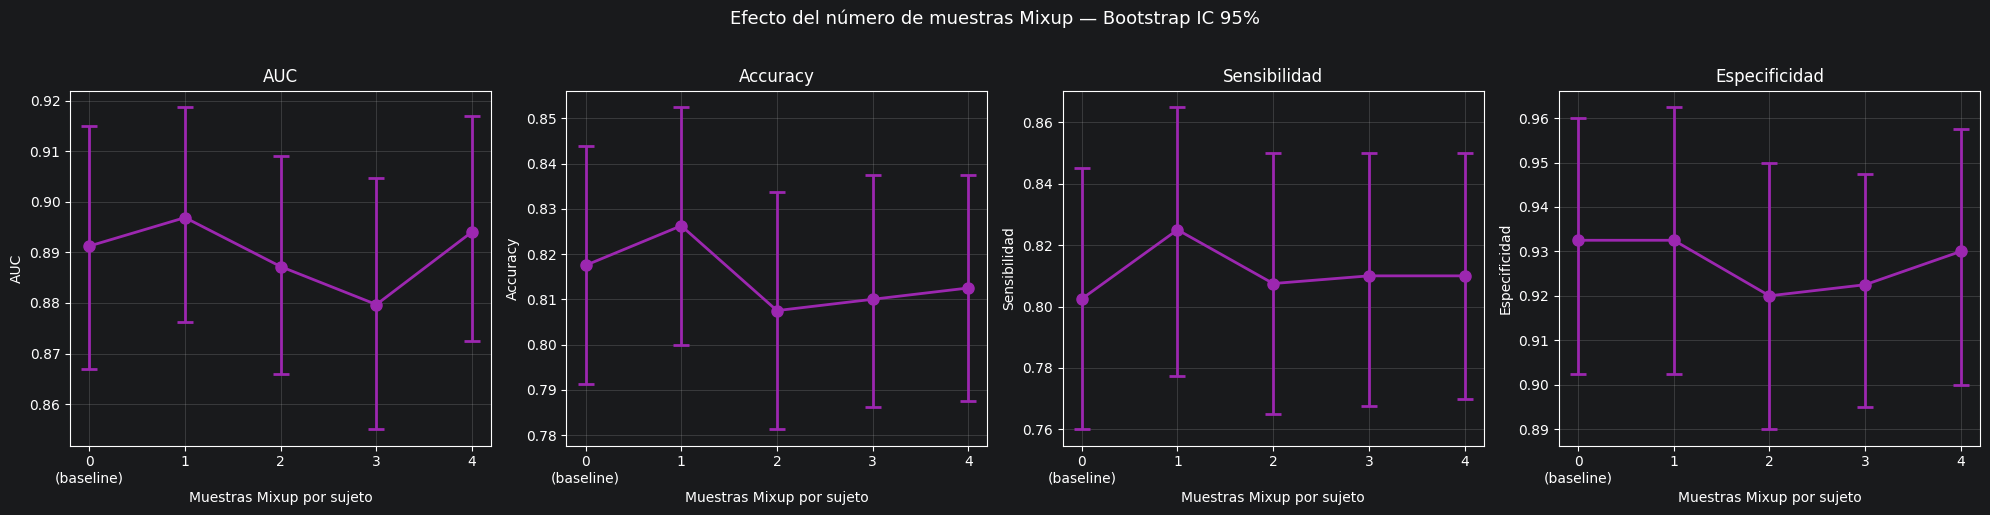

In [10]:
import matplotlib.pyplot as plt

def bootstrap_ci(values, n_bootstrap=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    values = np.array(values)
    boot_means = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(values), lower, upper

# === TABLA ===
print("=" * 85)
print("Efecto del número de muestras Mixup por sujeto")
print(f"Repeated {N_FOLDS}-Fold CV ({N_REPEATS} rep = {N_REPEATS*N_FOLDS} eval), Bootstrap IC 95%")
print("=" * 85)
print(f"  {'n_aug':<8} {'AUC':>25} {'Accuracy':>25}")
print(f"  {'─' * 58}")

for n_aug in N_AUG_OPTIONS:
    auc_m, auc_lo, auc_hi = bootstrap_ci(all_results[n_aug]["auc"])
    acc_m, acc_lo, acc_hi = bootstrap_ci(all_results[n_aug]["acc"])
    label = "baseline" if n_aug == 0 else f"{n_aug} mixup"
    print(f"  {label:<8} {auc_m:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]  {acc_m:.3f} [{acc_lo:.3f}, {acc_hi:.3f}]")

# === GRÁFICO ===
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ["auc", "acc", "sens", "spec"]
names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]
colors = ["#2196F3", "#9C27B0", "#4CAF50", "#FF9800", "#F44336"]

for ax, metric, name in zip(axes, metrics, names):
    means, lowers, uppers = [], [], []
    for n_aug in N_AUG_OPTIONS:
        m, lo, hi = bootstrap_ci(all_results[n_aug][metric])
        means.append(m)
        lowers.append(m - lo)
        uppers.append(hi - m)

    ax.errorbar(N_AUG_OPTIONS, means, yerr=[lowers, uppers],
                fmt='o-', color="#9C27B0", capsize=6, capthick=2, markersize=8, linewidth=2)

    ax.set_xlabel("Muestras Mixup por sujeto")
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.set_xticks(N_AUG_OPTIONS)
    ax.set_xticklabels(["0\n(baseline)", "1", "2", "3", "4"])
    ax.grid(True, alpha=0.3)

plt.suptitle("Efecto del número de muestras Mixup — Bootstrap IC 95%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Experimentos con otros encoders (HuBERT, WavLM) + Manifold Mixup

Probamos si un encoder diferente rompe el techo con los mismos datos y clasificador.

In [15]:
from src.embeddings import extract_multilayer_embeddings
from sklearn.preprocessing import StandardScaler

ENCODERS = {
    "wav2vec2": "facebook/wav2vec2-base",
    "HuBERT": "facebook/hubert-base-ls960",
    "WavLM": "microsoft/wavlm-base",
}

waveforms_all = [waveforms_processed[i] for i in train_idx] + [waveforms_processed[i] for i in test_idx]
n_train = len(train_idx)

encoder_data = {}
for name, model_id in ENCODERS.items():
    print(f"\nExtrayendo {name}...")
    layers = extract_multilayer_embeddings(waveforms_all, model_id, [0], DEVICE)
    emb = layers[0]

    sc = StandardScaler()
    t_train = sc.fit_transform(emb[:n_train])
    t_test = sc.transform(emb[n_train:])
    encoder_data[name] = (t_train, t_test)
    print(f"  {name}: dim={t_train.shape[1]}")

2026-04-19 22:05:12,593 [INFO] src.config:   Cargando facebook/wav2vec2-base...



Extrayendo wav2vec2...


2026-04-19 22:05:12,894 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-19 22:05:12,958 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-19 22:05:13,075 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-19 22:05:13,192 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-19 22:05:13,297 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-19 22:05:13,401 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Fou

  25/100
  50/100
  75/100


2026-04-19 22:05:16,591 [INFO] src.config:   Cargando facebook/hubert-base-ls960...
2026-04-19 22:05:16,694 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/hubert-base-ls960/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-19 22:05:16,760 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/hubert-base-ls960/dba3bb02fda4248b6e082697eee756de8fe8aa8a/config.json "HTTP/1.1 200 OK"


...

  25/100
  50/100
  75/100


2026-04-19 22:05:19,807 [INFO] src.config:   Cargando microsoft/wavlm-base...
2026-04-19 22:05:19,916 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-19 22:05:19,980 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/wavlm-base/efa81aae7ff777e464159e0f877d54eac5b84f81/config.json "HTTP/1.1 200 OK"
You are using a model of type `wavlm` to instantiate a model of type `wav2vec2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


  100/100
  HuBERT: dim=768

Extrayendo WavLM...


2026-04-19 22:05:20,085 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-19 22:05:20,189 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-19 22:05:20,303 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-19 22:05:20,405 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
Loading weights: 100%|██████████| 211/211 [00:00<00:00, 3002.32it/s, Materializing param=masked_spec_embed]                          
Wav2Vec2Model LOAD REPORT from: microsoft/wavlm-base
Key                                                         | Status     |  | 
------------------------------------------------------------+------------+--+-
encoder.layers.{0...

  25/100
  50/100
  75/100
  100/100
  WavLM: dim=768


In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve

N_REPEATS = 10
N_FOLDS = 5

bp_model = {
    "lr": 0.0007839314160797212,
    "weight_decay": 0.0002939827898456091,
    "dropout": 0.30,
    "label_smoothing": 0.0,
    "batch_size": 8,
    "dim_proj": 128,
    "dim_hidden": 64,
    "scheduler_factor": 0.5,
    "scheduler_patience": 7,
    "epochs": 120,
    "patience": 20,
}

all_encoder_results = {}

for enc_name in ENCODERS:
    print(f"\n{'='*50}")
    print(f"Evaluando {enc_name} + Mixup...")
    print(f"{'='*50}")

    emb_t_tr, emb_t_te = encoder_data[enc_name]

    rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    res = {"auc": [], "acc": [], "sens": [], "spec": []}

    for fold_idx, (tr_idx, val_idx) in enumerate(rskf.split(emb_t_tr, labels_train)):
        tr_t, tr_s, tr_l = emb_t_tr[tr_idx], emb_s_train[tr_idx], labels_train[tr_idx]

        rng = np.random.default_rng(RANDOM_STATE + fold_idx)
        aug_t, aug_s, aug_l = manifold_mixup_intraclass(tr_t, tr_s, tr_l, 0.8, rng)

        train_ds = DualBranchDataset(
            np.concatenate([tr_t, aug_t]), np.concatenate([tr_s, aug_s]),
            np.concatenate([tr_l, aug_l]), np.arange(len(tr_l) + len(aug_l))
        )
        val_ds = DualBranchDataset(emb_t_tr, emb_s_train, labels_train, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(train_ds, val_ds, DEVICE, **bp_model)
        y_pred = (y_prob >= 0.5).astype(int)
        fpr, tpr, _ = roc_curve(y_true, y_prob)

        res["auc"].append(roc_auc_score(y_true, y_prob))
        res["acc"].append(accuracy_score(y_true, y_pred))
        res["sens"].append(recall_score(y_true, y_pred, pos_label=1))
        res["spec"].append(1 - fpr[np.argmax(tpr - fpr)])

        if (fold_idx + 1) % N_FOLDS == 0:
            print(f"  Rep {(fold_idx+1)//N_FOLDS}/{N_REPEATS}")

    all_encoder_results[enc_name] = res
    print(f"  AUC: {np.mean(res['auc']):.3f} ± {np.std(res['auc']):.3f}")
    print(f"  Acc: {np.mean(res['acc']):.3f} ± {np.std(res['acc']):.3f}")


Evaluando wav2vec2 + Mixup...
  Rep 1/10
  Rep 2/10
  Rep 3/10
  Rep 4/10
  Rep 5/10
  Rep 6/10
  Rep 7/10
  Rep 8/10
  Rep 9/10
  Rep 10/10
  AUC: 0.888 ± 0.086
  Acc: 0.818 ± 0.086

Evaluando HuBERT + Mixup...
  Rep 1/10
  Rep 2/10
  Rep 3/10
  Rep 4/10
  Rep 5/10
  Rep 6/10
  Rep 7/10
  Rep 8/10
  Rep 9/10
  Rep 10/10
  AUC: 0.886 ± 0.078
  Acc: 0.795 ± 0.093

Evaluando WavLM + Mixup...
  Rep 1/10
  Rep 2/10
  Rep 3/10
  Rep 4/10
  Rep 5/10
  Rep 6/10
  Rep 7/10
  Rep 8/10
  Rep 9/10
  Rep 10/10
  AUC: 0.895 ± 0.075
  Acc: 0.821 ± 0.100


Comparación de encoders + Mixup — Repeated 5-Fold CV, Bootstrap IC 95%
  Métrica                          wav2vec2                    HuBERT                     WavLM
  ────────────────────────────────────────────────────────────────────────────────
  AUC                   0.888 [0.862,0.913]       0.886 [0.864,0.907]       0.895 [0.872,0.915]
  Accuracy              0.818 [0.794,0.843]       0.795 [0.769,0.821]       0.821 [0.792,0.850]
  Sensibilidad          0.815 [0.775,0.855]       0.770 [0.733,0.810]       0.818 [0.765,0.868]
  Especificidad         0.927 [0.890,0.960]       0.932 [0.907,0.955]       0.932 [0.907,0.955]


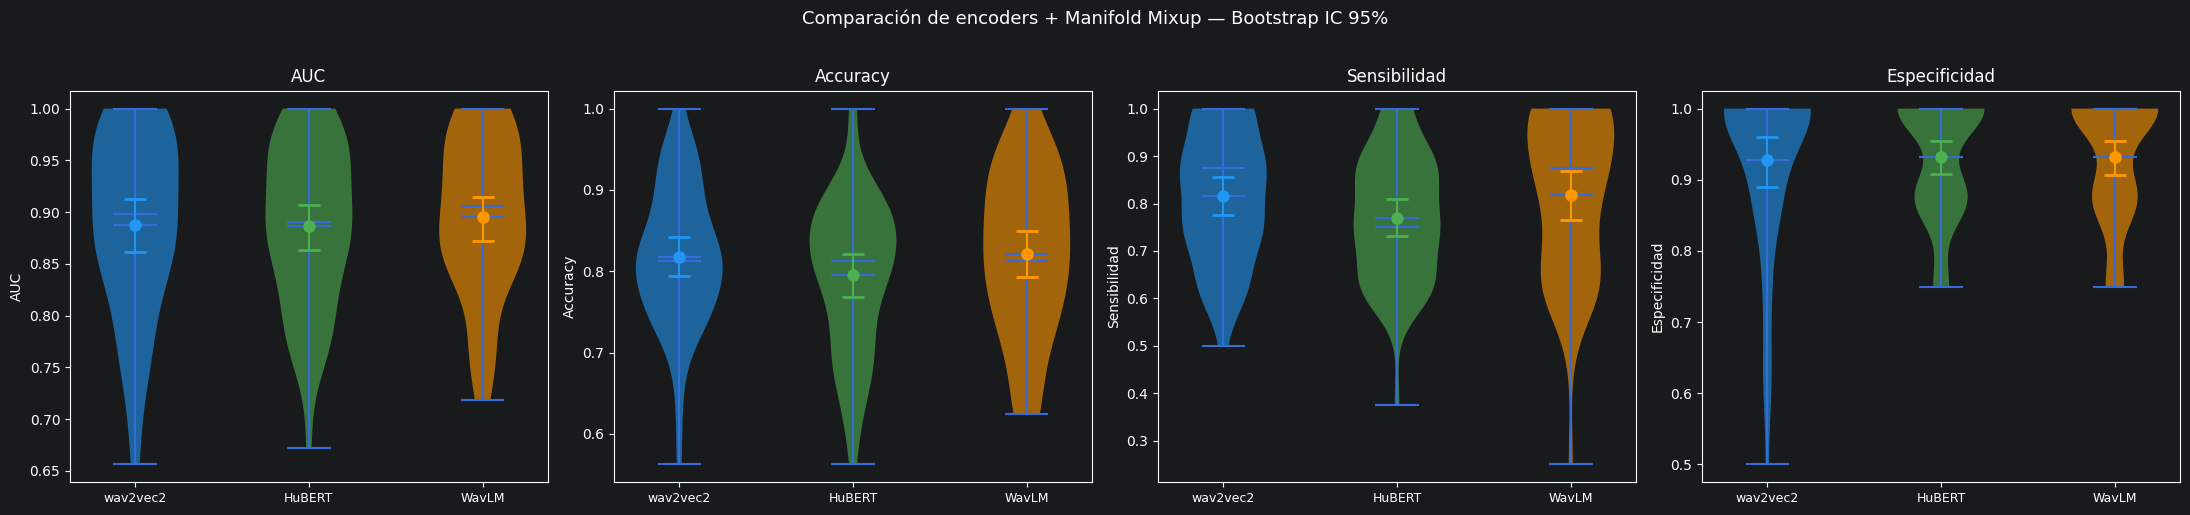

In [17]:
def bootstrap_ci(values, n_bootstrap=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    values = np.array(values)
    boot_means = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
    return np.mean(values), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)

# Tabla
print("=" * 95)
print(f"Comparación de encoders + Mixup — Repeated {N_FOLDS}-Fold CV, Bootstrap IC 95%")
print("=" * 95)
print(f"  {'Métrica':<15} {'wav2vec2':>25} {'HuBERT':>25} {'WavLM':>25}")
print(f"  {'─' * 80}")

for metric in ["auc", "acc", "sens", "spec"]:
    name = {"auc": "AUC", "acc": "Accuracy", "sens": "Sensibilidad", "spec": "Especificidad"}[metric]
    vals = []
    for enc in ENCODERS:
        m, lo, hi = bootstrap_ci(all_encoder_results[enc][metric])
        vals.append(f"{m:.3f} [{lo:.3f},{hi:.3f}]")
    print(f"  {name:<15} {vals[0]:>25} {vals[1]:>25} {vals[2]:>25}")

# Gráfico
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ["auc", "acc", "sens", "spec"]
names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, metric, name in zip(axes, metrics, names):
    data = [all_encoder_results[enc][metric] for enc in ENCODERS]
    parts = ax.violinplot(data, positions=[0, 1, 2], showmeans=True, showmedians=True)
    for i, color in enumerate(colors):
        parts["bodies"][i].set_facecolor(color)
        parts["bodies"][i].set_alpha(0.6)
    for i, (vals, color) in enumerate(zip(data, colors)):
        m, lo, hi = bootstrap_ci(vals)
        ax.errorbar(i, m, yerr=[[m-lo], [hi-m]], fmt='o', color=color, capsize=8, capthick=2, markersize=8)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(list(ENCODERS.keys()), fontsize=9)
    ax.set_title(name)
    ax.set_ylabel(name)

plt.suptitle("Comparación de encoders + Manifold Mixup — Bootstrap IC 95%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()